# Avance 5 – Modelo Final mediante Ensambles
## Proyecto Integrador – Equipo 22

Integrantes:
* María Virginia Mendizábal Miranda - A01796588
* Gianmel Joannelly Hernández Tosta - A01795919
* Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

**Fecha de entrega:** 7 de junio de 2026

---

## Objetivo del avance

En esta etapa se generan modelos de ensamble para mejorar el rendimiento predictivo obtenido en las fases previas, considerando tanto estrategias homogéneas como heterogéneas. Posteriormente se comparan contra el mejor modelo individual del Avance 4, se reportan métricas en datos no vistos y se selecciona el modelo final considerando desempeño, estabilidad, interpretabilidad y tiempo de entrenamiento.

### Objetivos de aprendizaje cubiertos

* **3.5:** Mejorar el rendimiento aprovechando las fortalezas de diferentes modelos y reduciendo sus debilidades.
* **3.6:** Evaluar la calidad de las predicciones del modelo en datos no vistos.


## 1. Librerías

Se utilizan librerías de `scikit-learn` para construir modelos individuales, ensambles homogéneos y ensambles heterogéneos. También se incluyen métricas multiclase, validación cruzada estratificada, curvas ROC y curvas Precision-Recall.


In [1]:
# ============================================================
# Librerías
# ============================================================

from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Modelos individuales de referencia / fase previa
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensambles homogéneos
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# Ensambles heterogéneos
from sklearn.ensemble import VotingClassifier, StackingClassifier

RANDOM_STATE = 42


## 2. Carga de datos

Esta libreta consume la matriz validada del Avance 2, manteniendo la trazabilidad del flujo CRISP-ML(Q). Para este avance se utiliza la matriz `X_intersect`, ya que fue la matriz seleccionada previamente por su robustez e interpretabilidad.

> Nota metodológica: en reuniones posteriores se podrá extender este mismo pipeline a otras matrices candidatas, como `X_top_MI`, `X_top_ANOVA` o el conjunto completo de variables. Sin embargo, para esta entrega se conserva la continuidad directa con el Avance 4.


In [2]:
# ============================================================
# Carga del dataset
# ============================================================

DATA_DIR = Path('.').resolve()
X_path = DATA_DIR / 'avance2_X_intersect.csv'
y_path = DATA_DIR / 'avance2_y.csv'

if not X_path.exists():
    raise FileNotFoundError(
        f'No se encontró {X_path.name}. Coloca avance2_X_intersect.csv en el mismo directorio de esta libreta.'
    )

if not y_path.exists():
    raise FileNotFoundError(
        f'No se encontró {y_path.name}. Coloca avance2_y.csv en el mismo directorio de esta libreta.'
    )

X = pd.read_csv(X_path)
y_df = pd.read_csv(y_path)

if 'group' in y_df.columns:
    y = y_df['group']
else:
    y = y_df.iloc[:, 0]

print(f'Ruta de datos: {DATA_DIR}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('\nDistribución de clases:')
print(y.value_counts())


Ruta de datos: /Users/gianmeltosta/proyecto_integrador_equipo-22/notebooks
X shape: (211, 16)
y shape: (211,)

Distribución de clases:
group
CTRL    78
CRC     75
AA      58
Name: count, dtype: int64


In [3]:
# ============================================================
# Verificación de integridad
# ============================================================

assert X.shape[0] == y.shape[0], 'X y y no tienen el mismo número de muestras.'
assert X.isna().sum().sum() == 0, 'X contiene valores faltantes.'
assert y.isna().sum() == 0, 'y contiene valores faltantes.'

clinical_cols = [c for c in ['age', 'fit_ug_g'] if c in X.columns]
categorical_cols = [c for c in X.columns if c.startswith(('gender_', 'fob_'))]
lipid_cols = [c for c in X.columns if c not in clinical_cols + categorical_cols]

print('Verificaciones aprobadas.')
print(f'Muestras: {X.shape[0]}')
print(f'Variables predictoras: {X.shape[1]}')
print(f'Variables clínicas: {clinical_cols}')
print(f'Variables categóricas: {categorical_cols}')
print(f'Biomarcadores lipidómicos/metabolómicos: {len(lipid_cols)}')


Verificaciones aprobadas.
Muestras: 211
Variables predictoras: 16
Variables clínicas: ['age', 'fit_ug_g']
Variables categóricas: ['gender_Male', 'fob_YES']
Biomarcadores lipidómicos/metabolómicos: 12


## 3. Estrategia de evaluación

Se mantiene una estrategia de evaluación en dos niveles:

| Nivel | Conjunto | Uso |
|---|---|---|
| Desarrollo | `X_dev` / `y_dev` | Ajuste de hiperparámetros mediante validación cruzada estratificada 5-fold |
| Prueba final | `X_test` / `y_test` | Evaluación final en datos no vistos |

Esta separación evita evaluar el modelo con los mismos datos utilizados para seleccionar hiperparámetros. La métrica principal será **F1 Macro**, porque el problema es multiclase y existe desbalance moderado entre CTRL, AA y CRC. También se reportan Accuracy, Precision Macro, Recall Macro y tiempos de entrenamiento.


In [4]:
# ============================================================
# Split dev/test con estratificación
# ============================================================

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f'X_dev:  {X_dev.shape}')
print(f'X_test: {X_test.shape}')
print('\nDistribución dev:')
print(y_dev.value_counts())
print('\nDistribución test:')
print(y_test.value_counts())


X_dev:  (168, 16)
X_test: (43, 16)

Distribución dev:
group
CTRL    62
CRC     60
AA      46
Name: count, dtype: int64

Distribución test:
group
CTRL    16
CRC     15
AA      12
Name: count, dtype: int64


## 4. Funciones auxiliares

Estas funciones permiten evaluar modelos de manera consistente, medir tiempos de entrenamiento y construir una tabla comparativa ordenada por F1 Macro.


In [5]:
# ============================================================
# Funciones auxiliares
# ============================================================

def evaluate_on_test(model, X_train, y_train, X_holdout, y_holdout):
    # Entrena en desarrollo y evalúa en datos no vistos.
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_holdout)

    return {
        'Accuracy': accuracy_score(y_holdout, y_pred),
        'Precision Macro': precision_score(y_holdout, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_holdout, y_pred, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_holdout, y_pred, average='macro', zero_division=0),
        'Training Time (s)': train_time,
        'y_pred': y_pred
    }


def grid_search_model(name, estimator, param_grid, X_train, y_train, cv, scoring='f1_macro'):
    # Ejecuta GridSearchCV y devuelve el mejor estimador, resultados CV y tiempo total.
    start = time.time()
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    grid.fit(X_train, y_train)
    elapsed = time.time() - start

    best_index = grid.best_index_
    cv_result = {
        'Model': name,
        'Best CV F1 Macro': grid.best_score_,
        'Train CV F1 Macro': grid.cv_results_['mean_train_score'][best_index],
        'Best Params': grid.best_params_,
        'Tuning Time (s)': elapsed
    }

    return grid.best_estimator_, cv_result, grid


## 5. Modelo individual de referencia del Avance 4

La rúbrica solicita incluir el mejor modelo individual de la fase previa. En el Avance 4 se seleccionó un **Decision Tree tuneado** por su balance entre desempeño, estabilidad e interpretabilidad. Aquí se vuelve a ajustar mediante validación cruzada para mantener la libreta autocontenida y reproducible.


In [6]:
# ============================================================
# Modelo individual de referencia: Decision Tree tuneado
# ============================================================

individual_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    'Gaussian NB': GaussianNB()
}

individual_param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs']
    },

    'Decision Tree': {
        'max_depth': [2, 3, 4, 5, None],
        'min_samples_leaf': [1, 2, 4, 6],
        'min_samples_split': [2, 4, 8],
        'criterion': ['gini', 'entropy']
    },

    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },

    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    },

    'Gaussian NB': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

best_individual_estimators = {}
individual_cv_rows = []
individual_test_rows = []

for name, estimator in individual_models.items():
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=individual_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_individual_estimators[name] = best_estimator
    individual_cv_rows.append(cv_row)

    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)
    individual_test_rows.append({
        'Model': name,
        'Type': 'Individual',
        'Strategy': 'Modelo individual fase previa',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

individual_results_df = pd.DataFrame(individual_test_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
individual_results_df


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,KNN,Individual,Modelo individual fase previa,0.676893,0.697674,0.690799,0.687500,0.687388,0.000991,0.184240,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,Logistic Regression,Individual,Modelo individual fase previa,0.611903,0.674419,0.675214,0.672222,0.669881,0.002192,1.431602,"{'model__C': 0.01, 'model__solver': 'lbfgs'}"
2,SVM,Individual,Modelo individual fase previa,0.594203,0.674419,0.660985,0.661111,0.660472,0.003565,0.164329,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
3,Decision Tree,Individual,Modelo individual fase previa,0.696094,0.651163,0.642136,0.641667,0.638560,0.001300,0.542833,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."
4,Gaussian NB,Individual,Modelo individual fase previa,0.564485,0.627907,0.630769,0.623611,0.623684,0.001241,0.077931,{'var_smoothing': 1e-09}


## 6. Ensambles homogéneos

Los ensambles homogéneos combinan modelos de la misma familia. En esta sección se entrenan cinco alternativas:

1. **Random Forest:** combina múltiples árboles mediante bagging y selección aleatoria de variables.
2. **Extra Trees:** variante de árboles extremadamente aleatorizados.
3. **Bagging Classifier:** aplica bootstrap agregando árboles de decisión como estimadores base.
4. **AdaBoost:** ensamble secuencial que corrige errores de modelos débiles anteriores.
5. **Gradient Boosting:** construye árboles secuenciales optimizando errores residuales.


In [7]:
# ============================================================
# Ensambles homogéneos
# ============================================================

homogeneous_models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Bagging Tree': BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'AdaBoost': AdaBoostClassifier(
        random_state=RANDOM_STATE
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

homogeneous_param_grids = {
    'Random Forest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },

    'Extra Trees': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },

    'Bagging Tree': {
        'n_estimators': [50, 100, 200],
        'max_samples': [0.6, 0.8, 1.0],
        'max_features': [0.6, 0.8, 1.0],
        'estimator__max_depth': [3, 5, None]
    },

    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3],
        'min_samples_leaf': [1, 3, 5]
    }
}

best_homogeneous_estimators = {}
homogeneous_rows = []

for name, estimator in homogeneous_models.items():
    print(f'Entrenando {name}...')
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=homogeneous_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_homogeneous_estimators[name] = best_estimator
    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)

    homogeneous_rows.append({
        'Model': name,
        'Type': 'Ensamble',
        'Strategy': 'Homogéneo',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

homogeneous_results_df = pd.DataFrame(homogeneous_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
homogeneous_results_df


Entrenando Random Forest...
Entrenando Extra Trees...
Entrenando Bagging Tree...
Entrenando AdaBoost...
Entrenando Gradient Boosting...


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Bagging Tree,Ensamble,Homogéneo,0.801625,0.860465,0.865320,0.852778,0.854809,0.036770,12.655452,"{'estimator__max_depth': None, 'max_features':..."
1,Random Forest,Ensamble,Homogéneo,0.805628,0.813953,0.819005,0.809722,0.809684,0.099075,18.828561,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
2,Gradient Boosting,Ensamble,Homogéneo,0.819610,0.813953,0.811111,0.808333,0.809140,0.307938,8.995538,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
3,AdaBoost,Ensamble,Homogéneo,0.752391,0.813953,0.811126,0.809722,0.808459,0.034991,1.238935,"{'learning_rate': 0.5, 'n_estimators': 50}"
4,Extra Trees,Ensamble,Homogéneo,0.737828,0.720930,0.711468,0.709722,0.709969,0.093506,16.165178,"{'max_depth': 7, 'max_features': 'sqrt', 'min_..."


## 7. Ensambles heterogéneos

Los ensambles heterogéneos combinan modelos de familias distintas. Para cumplir la rúbrica, se usan los modelos individuales de mejor rendimiento obtenidos en la fase previa como base para:

1. **Voting Classifier:** combina las probabilidades de modelos distintos mediante votación suave.
2. **Stacking Classifier:** utiliza las predicciones de modelos base como entrada para un meta-modelo final.

En ambos casos se seleccionan los mejores modelos individuales según F1 Macro en el conjunto de prueba reservado.


In [8]:
# ============================================================
# Selección de modelos base para ensambles heterogéneos
# ============================================================

base_model_names = individual_results_df.head(3)['Model'].tolist()
print('Modelos base seleccionados para Voting/Stacking:')
print(base_model_names)

base_estimators = []
for name in base_model_names:
    safe_name = name.lower().replace(' ', '_').replace('-', '_')
    base_estimators.append((safe_name, best_individual_estimators[name]))

base_estimators


Modelos base seleccionados para Voting/Stacking:
['KNN', 'Logistic Regression', 'SVM']


[('knn',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   KNeighborsClassifier(metric='manhattan', n_neighbors=7,
                                        weights='distance'))])),
 ('logistic_regression',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   LogisticRegression(C=0.01, class_weight='balanced',
                                      max_iter=5000, random_state=42))])),
 ('svm',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   SVC(C=0.1, class_weight='balanced', kernel='linear',
                       probability=True, random_state=42))]))]

In [9]:
# ============================================================
# Ensambles heterogéneos: Voting y Stacking
# ============================================================

heterogeneous_models = {
    'Voting Soft': VotingClassifier(
        estimators=base_estimators,
        voting='soft',
        n_jobs=-1
    ),

    'Stacking': StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        stack_method='predict_proba',
        cv=cv,
        n_jobs=-1
    )
}

# Se usan grids pequeños porque los modelos base ya fueron tuneados previamente.
heterogeneous_param_grids = {
    'Voting Soft': {
        'voting': ['soft']
    },

    'Stacking': {
        'final_estimator__C': [0.1, 1, 10]
    }
}

best_heterogeneous_estimators = {}
heterogeneous_rows = []

for name, estimator in heterogeneous_models.items():
    print(f'Entrenando {name}...')
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=heterogeneous_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_heterogeneous_estimators[name] = best_estimator
    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)

    heterogeneous_rows.append({
        'Model': name,
        'Type': 'Ensamble',
        'Strategy': 'Heterogéneo',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

heterogeneous_results_df = pd.DataFrame(heterogeneous_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
heterogeneous_results_df


Entrenando Voting Soft...
Entrenando Stacking...


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Stacking,Ensamble,Heterogéneo,0.681701,0.767442,0.759722,0.759722,0.759722,0.050552,0.298030,{'final_estimator__C': 0.1}
1,Voting Soft,Ensamble,Heterogéneo,0.632557,0.720930,0.711251,0.709722,0.709944,0.012451,0.063722,{'voting': 'soft'}


## 8. Tabla comparativa final

La tabla integra el mejor modelo individual de la fase previa y los modelos de ensamble generados en esta fase. Los modelos se ordenan por la métrica principal: **F1 Macro**.


In [10]:
# ============================================================
# Tabla comparativa final
# ============================================================

# Mejor modelo individual de la fase previa
best_individual_row = individual_results_df.head(1).copy()

comparison_df = pd.concat(
    [best_individual_row, homogeneous_results_df, heterogeneous_results_df],
    ignore_index=True
).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

# Redondeo para visualización
metrics_cols = ['Best CV F1 Macro', 'Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'Training Time (s)', 'Tuning Time (s)']
comparison_display = comparison_df.copy()
for col in metrics_cols:
    comparison_display[col] = comparison_display[col].astype(float).round(4)

comparison_display


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Bagging Tree,Ensamble,Homogéneo,0.8016,0.8605,0.8653,0.8528,0.8548,0.0368,12.6555,"{'estimator__max_depth': None, 'max_features':..."
1,Random Forest,Ensamble,Homogéneo,0.8056,0.8140,0.8190,0.8097,0.8097,0.0991,18.8286,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
2,Gradient Boosting,Ensamble,Homogéneo,0.8196,0.8140,0.8111,0.8083,0.8091,0.3079,8.9955,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
3,AdaBoost,Ensamble,Homogéneo,0.7524,0.8140,0.8111,0.8097,0.8085,0.0350,1.2389,"{'learning_rate': 0.5, 'n_estimators': 50}"
4,Stacking,Ensamble,Heterogéneo,0.6817,0.7674,0.7597,0.7597,0.7597,0.0506,0.2980,{'final_estimator__C': 0.1}
5,Extra Trees,Ensamble,Homogéneo,0.7378,0.7209,0.7115,0.7097,0.7100,0.0935,16.1652,"{'max_depth': 7, 'max_features': 'sqrt', 'min_..."
6,Voting Soft,Ensamble,Heterogéneo,0.6326,0.7209,0.7113,0.7097,0.7099,0.0125,0.0637,{'voting': 'soft'}
7,KNN,Individual,Modelo individual fase previa,0.6769,0.6977,0.6908,0.6875,0.6874,0.0010,0.1842,"{'model__metric': 'manhattan', 'model__n_neigh..."


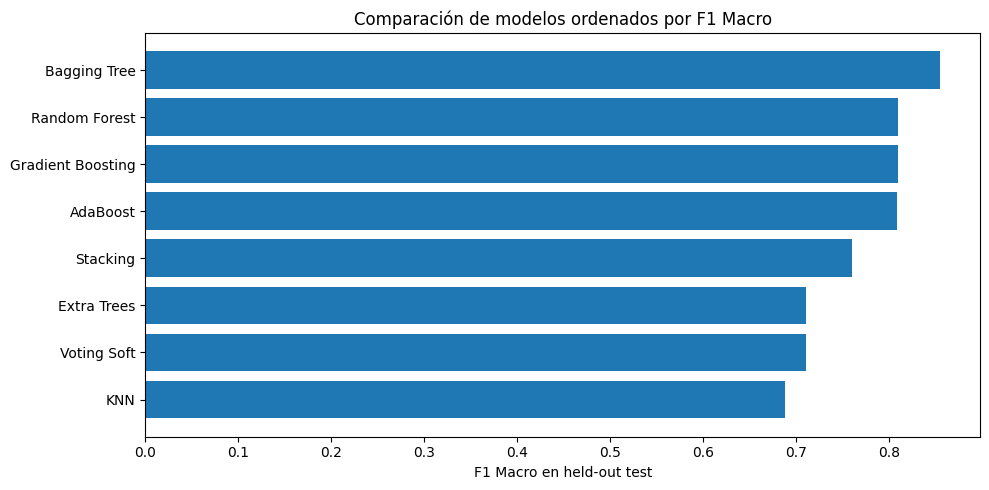

In [11]:
# ============================================================
# Visualización comparativa por F1 Macro
# ============================================================

plt.figure(figsize=(10, 5))
y_pos = np.arange(len(comparison_display))
plt.barh(y_pos, comparison_display['F1 Macro'])
plt.yticks(y_pos, comparison_display['Model'])
plt.gca().invert_yaxis()
plt.xlabel('F1 Macro en held-out test')
plt.title('Comparación de modelos ordenados por F1 Macro')
plt.tight_layout()
plt.show()


## 9. Selección del modelo final

El modelo final se selecciona considerando:

* F1 Macro en datos no vistos.
* Balance entre Precision Macro y Recall Macro.
* Estabilidad entre validación cruzada y held-out.
* Tiempo de entrenamiento.
* Interpretabilidad biomédica.

En contextos clínicos no basta con maximizar una métrica: también es necesario considerar si el modelo puede explicarse y si sus variables relevantes pueden discutirse con expertos biomédicos.


In [12]:
# ============================================================
# Selección automática del modelo final por F1 Macro
# ============================================================

final_model_name = comparison_df.iloc[0]['Model']
final_strategy = comparison_df.iloc[0]['Strategy']

all_estimators = {}
all_estimators.update(best_individual_estimators)
all_estimators.update(best_homogeneous_estimators)
all_estimators.update(best_heterogeneous_estimators)

final_model = all_estimators[final_model_name]
final_model.fit(X_dev, y_dev)
y_test_pred = final_model.predict(X_test)

print(f'Modelo final seleccionado: {final_model_name}')
print(f'Estrategia: {final_strategy}')
print('\nParámetros / configuración:')
print(final_model)
print('\nReporte de clasificación en held-out test:')
print(classification_report(y_test, y_test_pred, zero_division=0))


Modelo final seleccionado: Bagging Tree
Estrategia: Homogéneo

Parámetros / configuración:
BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=42),
                  max_features=0.6, max_samples=0.8, n_estimators=100,
                  n_jobs=-1, random_state=42)

Reporte de clasificación en held-out test:
              precision    recall  f1-score   support

          AA       0.82      0.75      0.78        12
         CRC       0.78      0.93      0.85        15
        CTRL       1.00      0.88      0.93        16

    accuracy                           0.86        43
   macro avg       0.87      0.85      0.85        43
weighted avg       0.87      0.86      0.86        43



### Interpretación de la selección

El modelo seleccionado corresponde al primer lugar en F1 Macro sobre el conjunto held-out. Esta métrica es adecuada porque pondera de manera equilibrada el desempeño por clase en un problema multiclase con desbalance moderado. Adicionalmente, se revisan Accuracy, Precision Macro, Recall Macro y tiempos de entrenamiento para evitar seleccionar un modelo con buen desempeño numérico pero poca estabilidad o alto costo computacional.

Si el modelo final corresponde a un ensamble basado en árboles, se puede interpretar mediante importancia de características. Si el modelo final corresponde a Voting o Stacking, la interpretación se apoya en el desempeño agregado y, cuando sea necesario, en las importancias o coeficientes de los modelos base.


## 10. Gráfico 1: Matriz de confusión

La matriz de confusión permite identificar qué clases se predicen correctamente y dónde ocurren los principales errores. En este proyecto es especialmente importante observar el comportamiento de la clase **AA**, ya que representa una lesión precancerosa y puede ser más difícil de separar de CTRL y CRC.


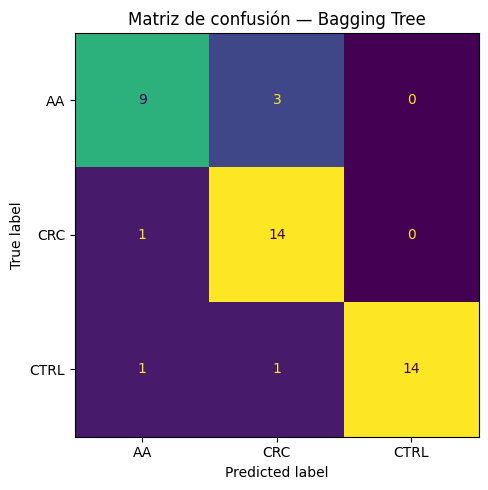

In [13]:
# ============================================================
# Matriz de confusión
# ============================================================

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
plt.title(f'Matriz de confusión — {final_model_name}')
plt.tight_layout()
plt.show()


### Interpretación

La matriz de confusión muestra el desempeño del modelo en datos no vistos. Las celdas diagonales representan predicciones correctas, mientras que las celdas fuera de la diagonal muestran confusiones entre clases. En un contexto biomédico, los errores relacionados con AA son particularmente relevantes porque esta clase representa una etapa intermedia y heterogénea entre CTRL y CRC.


## 11. Gráfico 2: Importancia de características

Este gráfico identifica los biomarcadores que más contribuyen al modelo final cuando el modelo cuenta con `feature_importances_`. Para ensambles heterogéneos sin importancia nativa, se utiliza una aproximación basada en el mejor modelo de árboles disponible.


El modelo final no cuenta con importancia nativa. Se usa Random Forest como apoyo interpretativo.


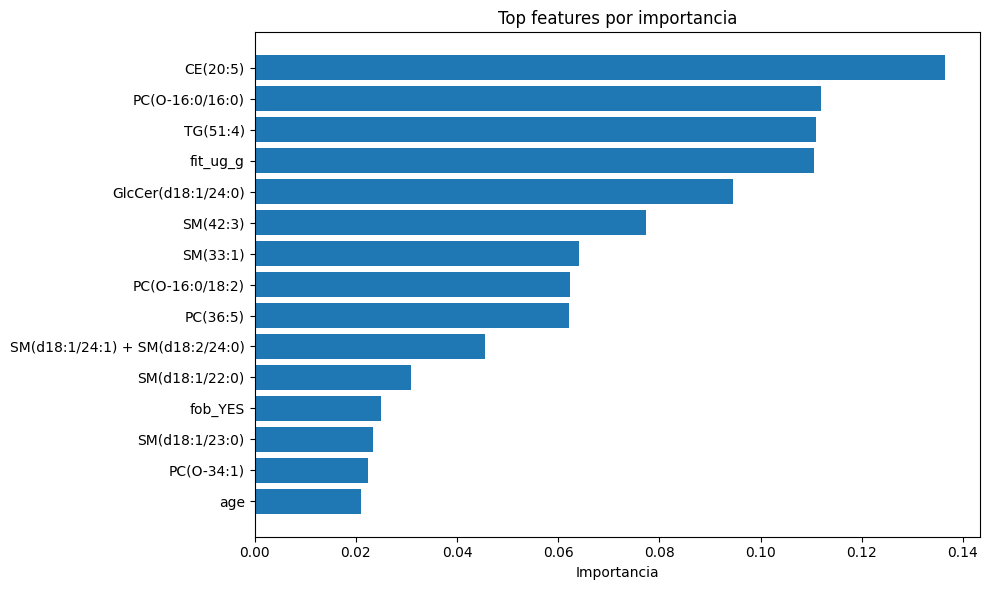

,Feature,Importance
0,CE(20:5),0.136558
1,PC(O-16:0/16:0),0.112030
2,TG(51:4),0.110994
3,fit_ug_g,0.110595
4,GlcCer(d18:1/24:0),0.094506
5,SM(42:3),0.077365
6,SM(33:1),0.064221
7,PC(O-16:0/18:2),0.062246
8,PC(36:5),0.062238
9,SM(d18:1/24:1) + SM(d18:2/24:0),0.045462


In [14]:
# ============================================================
# Importancia de características
# ============================================================

def get_feature_importance(model, feature_names):
    # Obtiene importancia de características si el modelo la soporta.
    if hasattr(model, 'feature_importances_'):
        return pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

    if hasattr(model, 'named_steps') and hasattr(model.named_steps.get('model', None), 'coef_'):
        coefs = np.abs(model.named_steps['model'].coef_).mean(axis=0)
        return pd.DataFrame({
            'Feature': feature_names,
            'Importance': coefs
        }).sort_values('Importance', ascending=False)

    return None

importance_df = get_feature_importance(final_model, X_dev.columns)

# Si el modelo final no tiene importancia directa, se usa Random Forest o Extra Trees como apoyo interpretativo.
if importance_df is None:
    fallback_name = 'Random Forest' if 'Random Forest' in best_homogeneous_estimators else 'Extra Trees'
    print(f'El modelo final no cuenta con importancia nativa. Se usa {fallback_name} como apoyo interpretativo.')
    fallback_model = best_homogeneous_estimators[fallback_name]
    fallback_model.fit(X_dev, y_dev)
    importance_df = get_feature_importance(fallback_model, X_dev.columns)

importance_df = importance_df.reset_index(drop=True)

top_n = min(15, len(importance_df))
plt.figure(figsize=(10, 6))
plt.barh(np.arange(top_n), importance_df.head(top_n)['Importance'])
plt.yticks(np.arange(top_n), importance_df.head(top_n)['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top features por importancia')
plt.tight_layout()
plt.show()

importance_df.head(20)


### Interpretación

Las variables con mayor importancia representan los biomarcadores o variables clínicas que más contribuyen a la clasificación entre CTRL, AA y CRC. Esta visualización permite conectar el desempeño predictivo con una interpretación biomédica preliminar. Los biomarcadores destacados deberán contrastarse con el análisis de selección de características y con la revisión clínica de los expertos.


## 12. Gráfico 3: Curvas ROC multiclase

Para problemas multiclase se calculan curvas ROC bajo el esquema *one-vs-rest*. Cada curva evalúa la capacidad del modelo para separar una clase específica frente al resto.


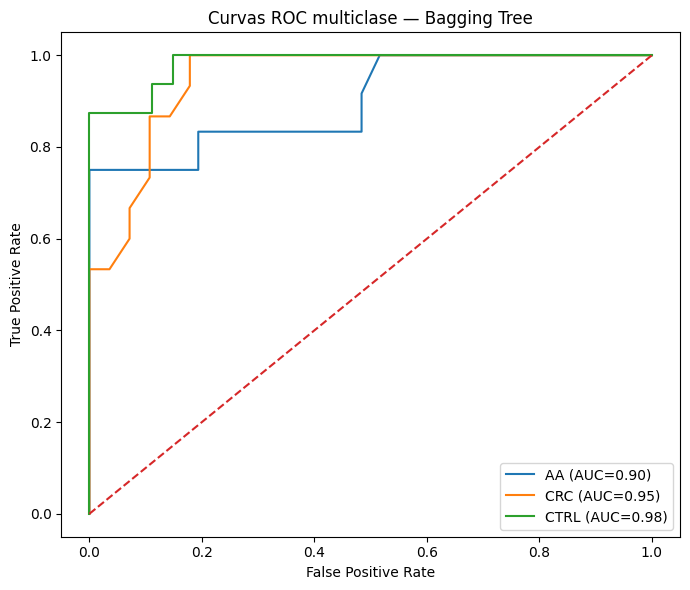

,Class,ROC AUC
0,AA,0.901882
1,CRC,0.948810
2,CTRL,0.983796


In [15]:
# ============================================================
# Curvas ROC multiclase
# ============================================================

def get_scores_for_curves(model, X_data):
    # Devuelve probabilidades o scores para curvas ROC/PR.
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_data)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        return scores
    raise ValueError('El modelo no soporta predict_proba ni decision_function.')

classes = np.array(sorted(y.unique()))
y_test_bin = label_binarize(y_test, classes=classes)
y_score = get_scores_for_curves(final_model, X_test)

# Asegurar orden de columnas si el clasificador guarda classes_
if hasattr(final_model, 'classes_'):
    model_classes = np.array(final_model.classes_)
    order = [list(model_classes).index(c) for c in classes]
    y_score = y_score[:, order]

plt.figure(figsize=(7, 6))
roc_auc = {}

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[cls] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc[cls]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curvas ROC multiclase — {final_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

pd.DataFrame({'Class': list(roc_auc.keys()), 'ROC AUC': list(roc_auc.values())})


### Interpretación

Las curvas ROC muestran qué tan bien el modelo separa cada clase frente a las demás. Un AUC cercano a 1 indica una separación fuerte; valores cercanos a 0.5 indican una separación similar al azar. En este problema se espera que CTRL y CRC sean más separables que AA, debido a que AA representa una etapa intermedia y biológicamente heterogénea.


## 13. Gráfico 4: Curvas Precision-Recall multiclase

Las curvas Precision-Recall son útiles cuando existe desbalance de clases. Permiten observar el equilibrio entre precisión y sensibilidad para cada clase.


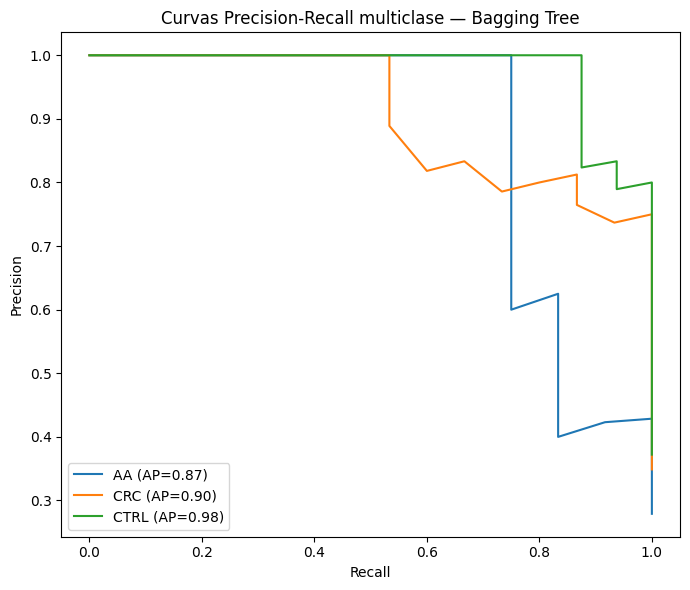

,Class,Average Precision
0,AA,0.873054
1,CRC,0.902438
2,CTRL,0.977083


In [16]:
# ============================================================
# Curvas Precision-Recall multiclase
# ============================================================

plt.figure(figsize=(7, 6))
average_precision = {}

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[cls] = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={average_precision[cls]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Curvas Precision-Recall multiclase — {final_model_name}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

pd.DataFrame({'Class': list(average_precision.keys()), 'Average Precision': list(average_precision.values())})


### Interpretación

Las curvas Precision-Recall permiten evaluar el desempeño del modelo cuando interesa mantener sensibilidad sin sacrificar demasiada precisión. En aplicaciones clínicas, esta visualización ayuda a valorar el riesgo de falsos negativos y falsos positivos por clase.


## 14. Gráfico 5: Classification report visual por clase

Además de los gráficos solicitados, se incluye una visualización de Precision, Recall y F1-score por clase para facilitar la interpretación del comportamiento específico en CTRL, AA y CRC.


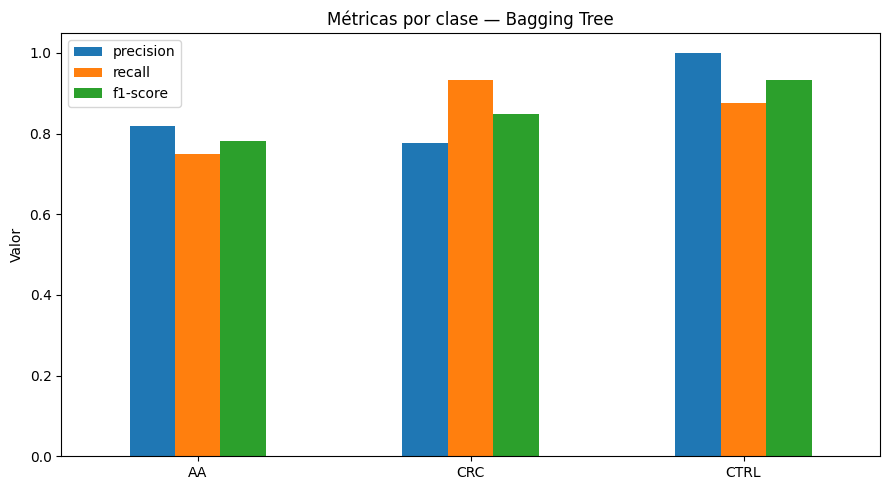

,precision,recall,f1-score
AA,0.818182,0.750000,0.782609
CRC,0.777778,0.933333,0.848485
CTRL,1.000000,0.875000,0.933333


In [17]:
# ============================================================
# Classification report visual
# ============================================================

report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[classes, ['precision', 'recall', 'f1-score']]

class_report_df.plot(kind='bar', figsize=(9, 5))
plt.title(f'Métricas por clase — {final_model_name}')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

class_report_df


### Interpretación

El reporte por clase permite identificar si el desempeño global está ocultando debilidades específicas. Si una clase presenta F1-score menor, se debe analizar si el problema se debe a baja precisión, bajo recall o ambos. En este proyecto, la clase AA requiere atención especial por su relevancia clínica como lesión precancerosa.


## 15. Conclusiones

1. Se generaron modelos de ensamble cubriendo ambas estrategias solicitadas: **homogéneas** y **heterogéneas**.
2. Se incluyeron más de cuatro ensambles: Random Forest, Extra Trees, Bagging, AdaBoost, Gradient Boosting, Voting y Stacking.
3. Se incorporó el mejor modelo individual de la fase previa para comparar el desempeño de los ensambles contra una línea base interpretativa.
4. Todos los modelos fueron evaluados en datos no vistos mediante un conjunto held-out, después de realizar ajuste de hiperparámetros con validación cruzada estratificada.
5. La selección del modelo final se realizó con base en F1 Macro, pero también considerando Precision Macro, Recall Macro, Accuracy, tiempo de entrenamiento e interpretabilidad.
6. Los gráficos del modelo final permiten analizar rendimiento global, errores por clase, capacidad de separación y variables relevantes.

### Implicación biomédica

El modelo final permite avanzar hacia una interpretación más robusta de los biomarcadores lipidómicos/metabolómicos asociados con la discriminación entre CTRL, AA y CRC. Las variables más importantes deberán analizarse junto con expertos clínicos para determinar si presentan coherencia con mecanismos biológicos esperados, especialmente en términos de familias lipídicas, longitud de cadena e insaturaciones.


## 16. Referencias

* Singh, A. (2023). *Comprehensive Guide to Ensemble Learning (with Python codes).* Analytics Vidhya.
* VanderPlas, J. (2022). *Python Data Science Handbook* (2nd ed.). O'Reilly Media.
* Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning.* Springer.
* Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107.
